<a href="https://www.kaggle.com/code/shamanthakreddymallu/s6e7-multi-model-blend?scriptVersionId=335366585" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Multi-Model Blend

Consumes saved OOF/test probability arrays from the individual model notebooks (added as *input notebooks*), searches blend weights on OOF, then re-optimizes the class-weight decision rule on the blended probabilities.

**Model notebooks this blend consumes (attach them as input notebooks):**

- [LightGBM](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-lightgbm)
- [CatBoost](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-catboost)
- [XGBoost](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-xgboost)
- [RealMLP](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-realmlp)
- [TabM](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-tabm)
- [Lookup Model](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-lookup-model)

In [1]:
# PATHS
TRAIN_PATH  = '/kaggle/input/competitions/playground-series-s6e7/train.csv'
SAMPLE_PATH = '/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv'

NB_BASE = '/kaggle/input/notebooks/shamanthakreddymallu'
ARTIFACTS = {
    'lgb':    (f'{NB_BASE}/s6e7-lightgbm/oof_lgb.npy',        f'{NB_BASE}/s6e7-lightgbm/test_lgb.npy'),
    'cat':    (f'{NB_BASE}/s6e7-catboost/oof_cat.npy',        f'{NB_BASE}/s6e7-catboost/test_cat.npy'),
    'xgb':    (f'{NB_BASE}/s6e7-xgboost/oof_xgb.npy',         f'{NB_BASE}/s6e7-xgboost/test_xgb.npy'),
    'mlp':    (f'{NB_BASE}/s6e7-realmlp/oof_mlp.npy',         f'{NB_BASE}/s6e7-realmlp/test_mlp.npy'),
    'tabm':   (f'{NB_BASE}/s6e7-tabm/oof_tabm.npy',           f'{NB_BASE}/s6e7-tabm/test_tabm.npy'),
    #'lookup': (f'{NB_BASE}/s6e7-lookup-model/oof_lookup.npy', f'{NB_BASE}/s6e7-lookup-model/test_lookup.npy'),
}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from scipy.optimize import minimize
from itertools import product, combinations
import warnings
warnings.filterwarnings('ignore')

TARGET = 'health_condition'
CLASS_COLORS = {'fit': '#55A868', 'at-risk': '#4C72B0', 'unhealthy': '#C44E52'}

train = pd.read_csv(TRAIN_PATH)
le    = LabelEncoder()
y_kag = le.fit_transform(train[TARGET])
print('Class encoding:', dict(zip(le.classes_, range(3))))
print(f'Train rows: {len(y_kag):,}')

Class encoding: {'at-risk': 0, 'fit': 1, 'unhealthy': 2}
Train rows: 690,088


# Load Model Artifacts

In [3]:
MODEL_NAMES = list(ARTIFACTS.keys())
oof_stack, test_stack = [], []

for name, (oof_path, test_path) in ARTIFACTS.items():
    o, t = np.load(oof_path), np.load(test_path)
    assert len(o) == len(y_kag), f'{name}: OOF length {len(o)} != train {len(y_kag)}'
    # renormalise rows defensively (fold-averaged probs can drift from summing to 1)
    o = o / o.sum(1, keepdims=True)
    t = t / t.sum(1, keepdims=True)
    oof_stack.append(o); test_stack.append(t)
    print(f'{name}: oof {o.shape}, test {t.shape}')

N_CLASSES = 3

lgb: oof (690088, 3), test (295753, 3)
cat: oof (690088, 3), test (295753, 3)
xgb: oof (690088, 3), test (295753, 3)
mlp: oof (690088, 3), test (295753, 3)
tabm: oof (690088, 3), test (295753, 3)


In [4]:
STRESS_MISSING = train['stress_level'].isna().values
SLEEP_MISSING  = train['sleep_duration'].isna().values
sleep = train['sleep_duration'].values
JITTER = (~SLEEP_MISSING) & (((sleep > 5.9) & (sleep < 6.15)) | ((sleep > 6.95) & (sleep < 7.1)))

stress = train['stress_level'].fillna('missing').values
SEGMENTS = {
    'stress=low':     stress == 'low',
    'stress=medium':  stress == 'medium',
    'stress=high':    stress == 'high',
    'stress=missing': STRESS_MISSING,
    'sleep=missing':  SLEEP_MISSING,
    'jitter band':    JITTER,
    'both present':   (~STRESS_MISSING) & (~SLEEP_MISSING),
}
for k, m in SEGMENTS.items():
    print(f'{k:16s}: {m.sum():>7,} rows ({m.mean()*100:.1f}%)')

stress=low      : 167,708 rows (24.3%)
stress=medium   : 261,819 rows (37.9%)
stress=high     : 177,750 rows (25.8%)
stress=missing  :  82,811 rows (12.0%)
sleep=missing   :  75,999 rows (11.0%)
jitter band     :  59,082 rows (8.6%)
both present    : 540,291 rows (78.3%)


# Decision-Rule Optimizer (shared)

In [5]:
def optimize_class_weights(probs, y_true, coarse=31, refine=25):
    grid       = np.exp(np.linspace(np.log(0.5), np.log(40), coarse))
    best_score = balanced_accuracy_score(y_true, probs.argmax(1))
    best_w     = np.ones(3)
    for wf, wu in product(grid, grid):
        w = np.array([1.0, wf, wu])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    if refine:
        ff = np.linspace(best_w[1] * 0.8, best_w[1] * 1.2, refine)
        fu = np.linspace(best_w[2] * 0.8, best_w[2] * 1.2, refine)
        for wf, wu in product(ff, fu):
            w = np.array([1.0, wf, wu])
            s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
            if s > best_score:
                best_score, best_w = s, w
    return best_w, best_score

# Individual Model Scores (baseline table)

In [6]:
single_results = {}
for name, o in zip(MODEL_NAMES, oof_stack):
    raw = balanced_accuracy_score(y_kag, o.argmax(1))
    w, opt = optimize_class_weights(o, y_kag)
    single_results[name] = dict(raw=raw, opt=opt, w=w)
    print(f'{name}: raw={raw:.5f}   weight-opt={opt:.5f}   weights={w.round(3)}')

BEST_SINGLE_NAME  = max(single_results, key=lambda k: single_results[k]['opt'])
BEST_SINGLE_SCORE = single_results[BEST_SINGLE_NAME]['opt']
print(f'\nBest single model: {BEST_SINGLE_NAME} ({BEST_SINGLE_SCORE:.5f})')

lgb: raw=0.92339   weight-opt=0.94854   weights=[ 1.    15.541 13.189]
cat: raw=0.94931   weight-opt=0.94942   weights=[1.    1.321 1.072]
xgb: raw=0.94698   weight-opt=0.94885   weights=[1.    2.047 2.079]
mlp: raw=0.87305   weight-opt=0.94776   weights=[ 1.    15.587 11.101]
tabm: raw=0.87180   weight-opt=0.94795   weights=[ 1.    13.598 13.676]

Best single model: cat (0.94942)


# Model Diversity — Pairwise Probability Correlations

The diagnostic that predicts blend value: correlations near 1.0 per class mean the models rank rows identically and blending adds nothing; ~0.95 or below leaves room.

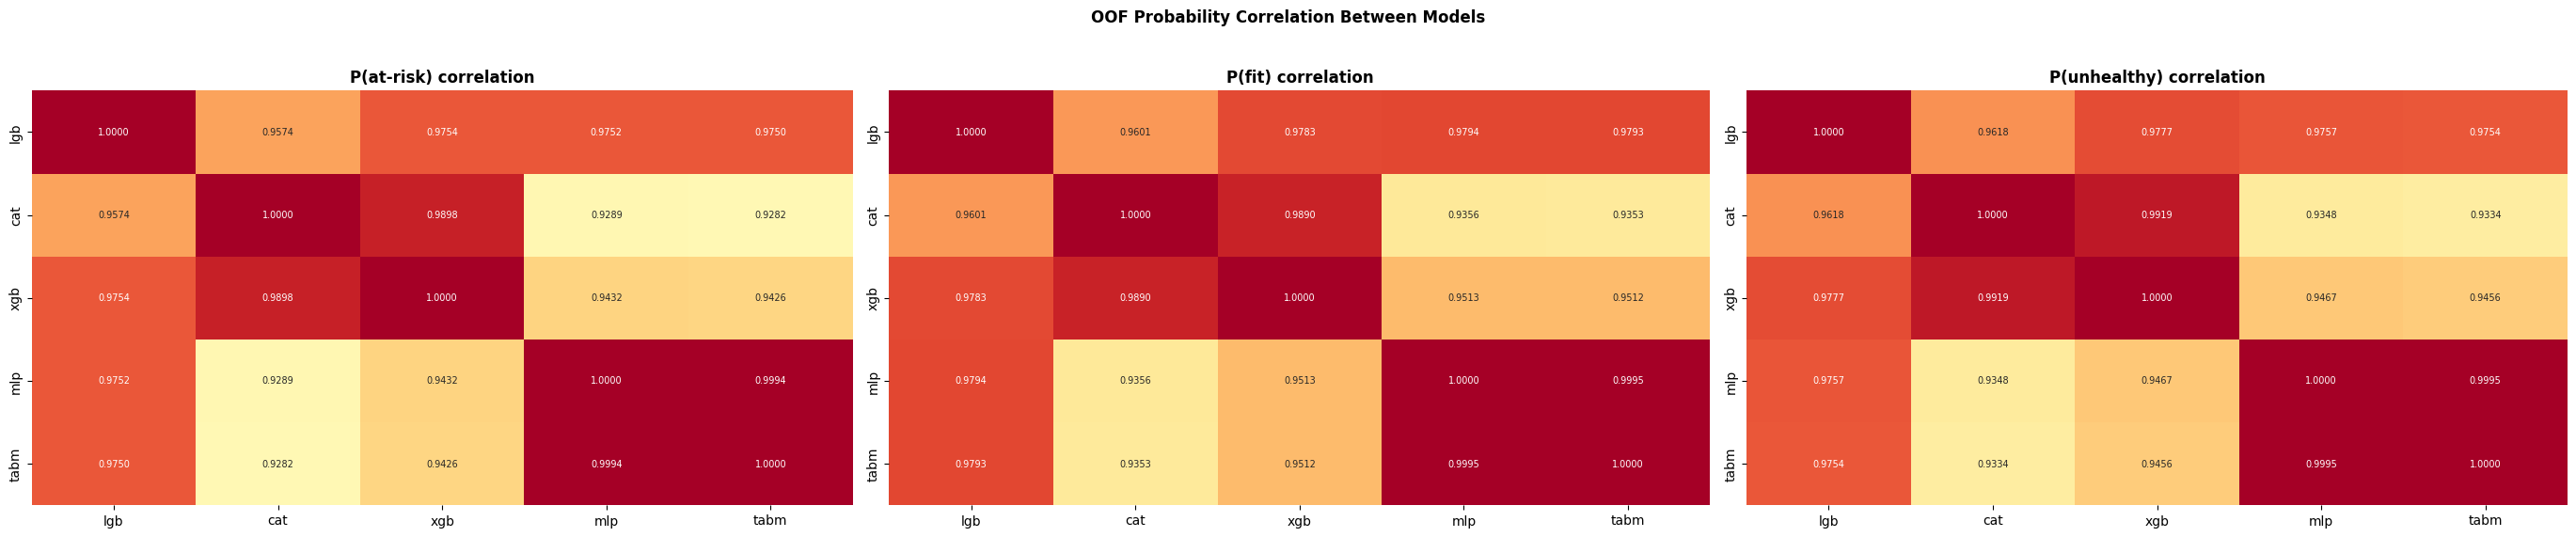

Pairwise argmax disagreement rate:
  lgb vs cat: 3.71%
  lgb vs xgb: 2.81%
  lgb vs mlp: 3.26%
  lgb vs tabm: 3.32%
  cat vs xgb: 1.09%
  cat vs mlp: 6.83%
  cat vs tabm: 6.91%
  xgb vs mlp: 5.94%
  xgb vs tabm: 6.01%
  mlp vs tabm: 0.32%


In [7]:
n_m = len(MODEL_NAMES)
fig, axes = plt.subplots(1, 3, figsize=(max(16, 5.5 * n_m), max(4.5, 1.1 * n_m)))

for cls_idx, cls_name in enumerate(le.classes_):
    corr = np.ones((n_m, n_m))
    for (i, oi), (j, oj) in combinations(enumerate(oof_stack), 2):
        c = np.corrcoef(oi[:, cls_idx], oj[:, cls_idx])[0, 1]
        corr[i, j] = corr[j, i] = c
    sns.heatmap(corr, annot=True, fmt='.4f', cmap='RdYlGn_r', vmin=0.85, vmax=1.0,
                xticklabels=MODEL_NAMES, yticklabels=MODEL_NAMES,
                ax=axes[cls_idx], cbar=False, annot_kws={'size': max(7, 11 - n_m)})
    axes[cls_idx].set_title(f'P({cls_name}) correlation', fontweight='bold')

plt.suptitle('OOF Probability Correlation Between Models', fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

print('Pairwise argmax disagreement rate:')
for (i, oi), (j, oj) in combinations(enumerate(oof_stack), 2):
    d = (oi.argmax(1) != oj.argmax(1)).mean()
    print(f'  {MODEL_NAMES[i]} vs {MODEL_NAMES[j]}: {d*100:.2f}%')

# Blend Weight Search

Nelder-Mead on the simplex (as in S6E6), but the objective here is the **weight-optimized** balanced accuracy of the blend — the decision rule must be re-fit for every candidate blend because blending changes calibration (LGBM needs ~14x multipliers, CatBoost ~1x; their mix lands somewhere in between). A coarse rule fit inside the objective keeps it fast; the final rule is refit with full resolution.

In [8]:
def blend_objective(w_raw):
    w = np.abs(w_raw); w = w / w.sum()
    blended = sum(wi * p for wi, p in zip(w, oof_stack))
    _, s = optimize_class_weights(blended, y_kag, coarse=17, refine=0)
    return -s

n_m = len(oof_stack)
skew = np.array([single_results[m]['opt'] for m in MODEL_NAMES]) ** 50
starts = [np.ones(n_m) / n_m, skew / skew.sum()]

best_res = None
for x0 in starts:
    res = minimize(blend_objective, x0=x0, method='Nelder-Mead',
                   options=dict(xatol=1e-3, fatol=1e-6, maxiter=150 * n_m))
    if best_res is None or res.fun < best_res.fun:
        best_res = res

blend_w = np.abs(best_res.x) / np.abs(best_res.x).sum()

print('Blend weights:')
for name, w in zip(MODEL_NAMES, blend_w):
    print(f'  {name}: {w:.3f}')

oof_blend  = sum(wi * p for wi, p in zip(blend_w, oof_stack))
test_blend = sum(wi * p for wi, p in zip(blend_w, test_stack))

global_w, blend_score = optimize_class_weights(oof_blend, y_kag, coarse=31, refine=25)
print(f'\nBlend OOF (weight-opt): {blend_score:.5f}')
print(f'Best single ({BEST_SINGLE_NAME}) : {BEST_SINGLE_SCORE:.5f}')
print(f'Blend gain              : {blend_score - BEST_SINGLE_SCORE:+.5f}')
print(f'Decision weights on blend: {dict(zip(le.classes_, global_w.round(4)))}')

Blend weights:
  lgb: 0.203
  cat: 0.218
  xgb: 0.204
  mlp: 0.188
  tabm: 0.186

Blend OOF (weight-opt): 0.94941
Best single (cat) : 0.94942
Blend gain              : -0.00001
Decision weights on blend: {'at-risk': np.float64(1.0), 'fit': np.float64(3.8759), 'unhealthy': np.float64(3.4625)}


# Post-Blend Analysis

## Confusion Matrix + Subgroup

Blend OOF Balanced Accuracy: 0.94941

              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    592561
         fit       0.73      0.95      0.83     39803
   unhealthy       0.69      0.96      0.80     57724

    accuracy                           0.94    690088
   macro avg       0.81      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088



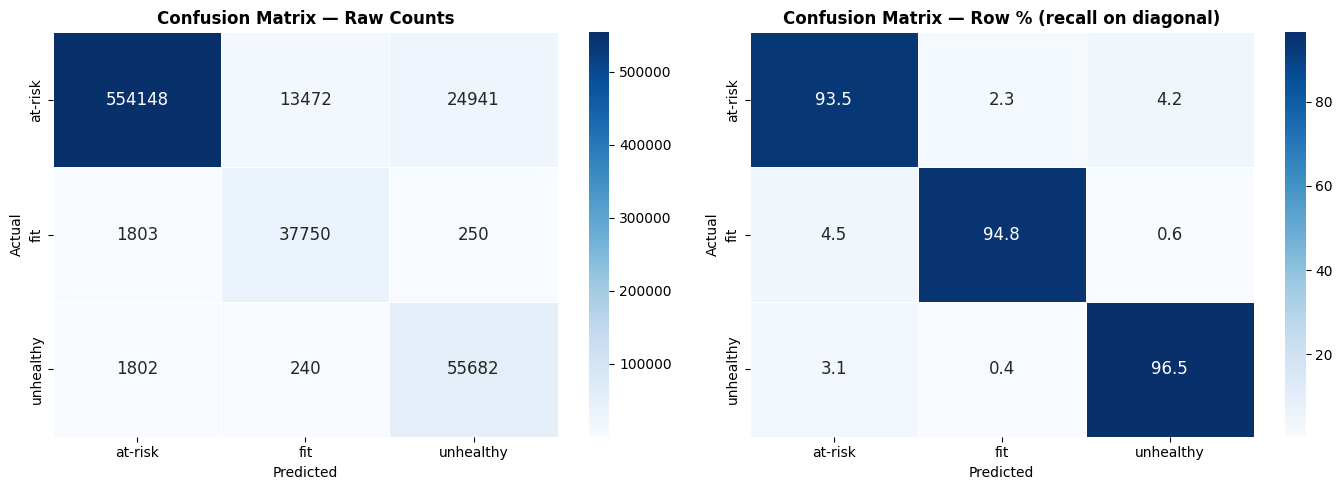

stress present  : balanced_acc = 0.96148   (n=607,277)
stress MISSING  : balanced_acc = 0.86086   (n=82,811)


In [9]:
probs_kag = oof_blend * global_w
preds_kag = probs_kag.argmax(1)

cm     = confusion_matrix(y_kag, preds_kag)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

print(f'Blend OOF Balanced Accuracy: {blend_score:.5f}')
print()
print(classification_report(y_kag, preds_kag, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix — Row % (recall on diagonal)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

# stress-missing subgroup
stress_missing = train['stress_level'].isna().values
for name, mask in [('stress present', ~stress_missing), ('stress MISSING', stress_missing)]:
    s = balanced_accuracy_score(y_kag[mask], preds_kag[mask])
    print(f'{name:16s}: balanced_acc = {s:.5f}   (n={mask.sum():,})')

## Where do the models disagree? (blend value inspection)

In [10]:
argmaxes = np.stack([o.argmax(1) for o in oof_stack])
disagree = (argmaxes != argmaxes[0]).any(0)
print(f'Rows where models disagree: {disagree.sum():,} ({disagree.mean()*100:.2f}%)')

acc_on_disagree = {}
for name, o in zip(MODEL_NAMES, oof_stack):
    acc_on_disagree[name] = balanced_accuracy_score(y_kag[disagree], o[disagree].argmax(1))
acc_on_disagree['blend'] = balanced_accuracy_score(y_kag[disagree], preds_kag[disagree])

print('\nBalanced accuracy ON DISAGREEMENT ROWS ONLY:')
for k, v in acc_on_disagree.items():
    print(f'  {k:6s}: {v:.5f}')

Rows where models disagree: 49,358 (7.15%)

Balanced accuracy ON DISAGREEMENT ROWS ONLY:
  lgb   : 0.60742
  cat   : 0.65710
  xgb   : 0.67535
  mlp   : 0.35612
  tabm  : 0.35077
  blend : 0.65986


## Per-segment model comparison

In [11]:
# Each model gets its own GLOBAL decision weights (from single_results),
# then we score those predictions inside each segment.
rows = []
for seg_name, mask in SEGMENTS.items():
    row = {'segment': seg_name, 'n': mask.sum()}
    for name, o in zip(MODEL_NAMES, oof_stack):
        p = (o * single_results[name]['w']).argmax(1)
        row[name] = balanced_accuracy_score(y_kag[mask], p[mask])
    rows.append(row)

seg_table = pd.DataFrame(rows).set_index('segment')
print(seg_table.round(5).to_string())
print('\nBest model per segment:')
print(seg_table.drop(columns='n').idxmax(axis=1).to_string())

                     n      lgb      cat      xgb      mlp     tabm
segment                                                            
stress=low      167708  0.65422  0.65259  0.65436  0.65271  0.65399
stress=medium   261819  0.33989  0.33743  0.33595  0.33661  0.33701
stress=high     177750  0.63235  0.63264  0.63271  0.62950  0.62800
stress=missing   82811  0.85661  0.86127  0.85928  0.85557  0.85668
sleep=missing    75999  0.85794  0.86117  0.85966  0.85586  0.85607
jitter band      59082  0.89430  0.89751  0.89373  0.88713  0.88736
both present    540291  0.97024  0.97054  0.97020  0.96981  0.96980

Best model per segment:
segment
stress=low        xgb
stress=medium     lgb
stress=high       xgb
stress=missing    cat
sleep=missing     cat
jitter band       cat
both present      cat


## Segmented decision weights (bootstrap-median)

In [12]:
rng = np.random.default_rng(42)
oof_cat = oof_stack[MODEL_NAMES.index('cat')]

def boot_median_weights(probs, y, n_boot=50):
    ws = []
    idx_all = np.arange(len(y))
    for _ in range(n_boot):
        idx = rng.choice(idx_all, size=len(y), replace=True)
        w, _ = optimize_class_weights(probs[idx], y[idx], coarse=17, refine=0)
        ws.append(w)
    return np.median(ws, axis=0)

# disjoint segmentation: both-present / stress-missing / sleep-missing(only)
seg_masks = {
    'both present':   SEGMENTS['both present'],
    'stress missing': STRESS_MISSING,
    'sleep missing':  SLEEP_MISSING & ~STRESS_MISSING,
}
assert sum(m.sum() for m in seg_masks.values()) == len(y_kag)

preds_seg = np.empty(len(y_kag), dtype=int)
for name, mask in seg_masks.items():
    w = boot_median_weights(oof_cat[mask], y_kag[mask])
    preds_seg[mask] = (oof_cat[mask] * w).argmax(1)
    print(f'{name:15s}: boot-median w = {w.round(3)}')

seg_score = balanced_accuracy_score(y_kag, preds_seg)
base = single_results['cat']['opt']
print(f'\nSegmented OOF : {seg_score:.5f}   global: {base:.5f}   Δ = {seg_score-base:+.5f}')
print('PASS needs Δ > +0.0005' )

both present   : boot-median w = [1.    1.137 1.495]
stress missing : boot-median w = [1.    1.495 1.137]
sleep missing  : boot-median w = [1.    1.966 1.137]

Segmented OOF : 0.94946   global: 0.94942   Δ = +0.00004
PASS needs Δ > +0.0005


## Confidence routing: blend when uncertain

In [13]:
cat_w = oof_cat * single_results['cat']['w']
conf = np.sort(cat_w / cat_w.sum(1, keepdims=True), axis=1)
margin = conf[:, -1] - conf[:, -2]          # top-2 margin on weighted cat probs

blend_preds = (oof_blend * global_w).argmax(1)
cat_preds   = cat_w.argmax(1)

print(f'{"tau":>5s}  {"routed to blend":>16s}  OOF')
best_tau, best_s = None, base
for tau in [0.02, 0.05, 0.1, 0.2, 0.3, 0.5]:
    p = np.where(margin < tau, blend_preds, cat_preds)
    s = balanced_accuracy_score(y_kag, p)
    print(f'{tau:5.2f}  {(margin < tau).sum():>12,} rows  {s:.5f}')
    if s > best_s: best_tau, best_s = tau, s
print(f'\nBest: tau={best_tau}, {best_s:.5f} vs cat {base:.5f}  (PASS > +0.0005)')

  tau   routed to blend  OOF
 0.02           865 rows  0.94939
 0.05         2,250 rows  0.94935
 0.10         4,501 rows  0.94938
 0.20         8,692 rows  0.94946
 0.30        13,379 rows  0.94941
 0.50        24,069 rows  0.94942

Best: tau=0.2, 0.94946 vs cat 0.94942  (PASS > +0.0005)


## Level-2 stacker

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

meta_X = np.hstack(oof_stack +
                   [STRESS_MISSING[:, None], SLEEP_MISSING[:, None], JITTER[:, None]]).astype(float)
print(f'Meta features: {meta_X.shape}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # same folds as base models

for tag, make in [('LogReg', lambda: LogisticRegression(max_iter=1000, C=1.0)),
                  ('LGBM-d2', lambda: LGBMClassifier(objective='multiclass', num_class=3,
                        max_depth=2, n_estimators=200, learning_rate=0.05,
                        reg_lambda=10.0, class_weight='balanced',
                        random_state=42, verbose=-1))]:
    oof_meta = np.zeros((len(y_kag), 3))
    for tr, va in skf.split(meta_X, y_kag):
        m = make(); m.fit(meta_X[tr], y_kag[tr])
        oof_meta[va] = m.predict_proba(meta_X[va])
    w, s = optimize_class_weights(oof_meta, y_kag)
    print(f'{tag:8s}: stacker OOF (weight-opt) = {s:.5f}   Δ vs cat = {s-base:+.5f}')

Meta features: (690088, 18)
LogReg  : stacker OOF (weight-opt) = 0.94934   Δ vs cat = -0.00008
LGBM-d2 : stacker OOF (weight-opt) = 0.94943   Δ vs cat = +0.00001


## Temperature + bootstrap-median global weights

In [15]:
# joint temperature × weights
best_t, best_ts = 1.0, base
for T in [0.5, 0.7, 1.0, 1.5, 2.0, 3.0]:
    _, s = optimize_class_weights(oof_cat ** T, y_kag, coarse=25, refine=15)
    print(f'T={T:.1f}: {s:.5f}')
    if s > best_ts: best_t, best_ts = T, s
print(f'Best T={best_t}: Δ = {best_ts-base:+.5f}  (PASS > +0.0005)\n')

# bootstrap-median global weights — stability check + safer submission weights
w_med = boot_median_weights(oof_cat, y_kag, n_boot=50)
s_med = balanced_accuracy_score(y_kag, (oof_cat * w_med).argmax(1))
print(f'Point-estimate w: {single_results["cat"]["w"].round(3)} → {base:.5f}')
print(f'Boot-median   w: {w_med.round(3)} → {s_med:.5f}')
print('If scores ~equal: plateau confirmed, median is the safer test-time choice.')

T=0.5: 0.94941
T=0.7: 0.94941
T=1.0: 0.94943
T=1.5: 0.94942
T=2.0: 0.94941
T=3.0: 0.94944
Best T=3.0: Δ = +0.00002  (PASS > +0.0005)

Point-estimate w: [1.    1.321 1.072] → 0.94942
Boot-median   w: [1.    1.495 1.137] → 0.94939
If scores ~equal: plateau confirmed, median is the safer test-time choice.


# Submission

Saved: submission.csv (+ oof_blend.npy / test_blend.npy)

Blend weights: {'lgb': np.float64(0.203), 'cat': np.float64(0.218), 'xgb': np.float64(0.204), 'mlp': np.float64(0.188), 'tabm': np.float64(0.186)}
Decision weights: {'at-risk': np.float64(1.0), 'fit': np.float64(3.8759), 'unhealthy': np.float64(3.4625)}

Predicted class distribution (test):
at-risk      239452
unhealthy     34563
fit           21738

Train distribution for reference:
health_condition
at-risk      592561
unhealthy     57724
fit           39803


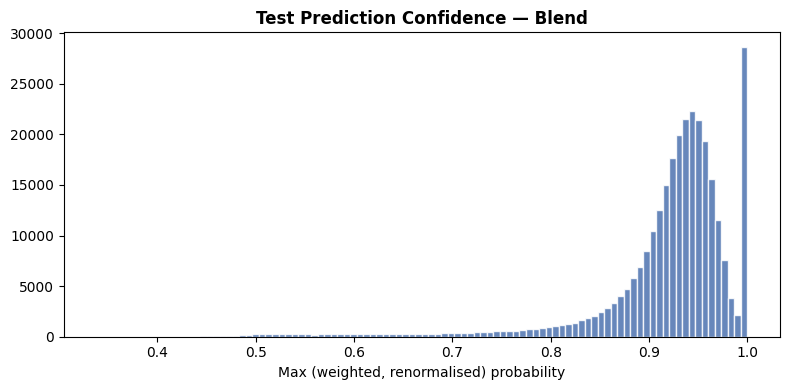

In [16]:
test_w = test_blend * global_w
labels = le.inverse_transform(test_w.argmax(1))

sub = pd.read_csv(SAMPLE_PATH)
sub[TARGET] = labels
sub.to_csv('submission.csv', index=False)

np.save('oof_blend.npy', oof_blend)
np.save('test_blend.npy', test_blend)

print('Saved: submission.csv (+ oof_blend.npy / test_blend.npy)')
print(f'\nBlend weights: {dict(zip(MODEL_NAMES, blend_w.round(3)))}')
print(f'Decision weights: {dict(zip(le.classes_, global_w.round(4)))}')
print('\nPredicted class distribution (test):')
print(pd.Series(labels).value_counts().to_string())
print('\nTrain distribution for reference:')
print(train[TARGET].value_counts().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
norm_p = test_w / test_w.sum(1, keepdims=True)
ax.hist(norm_p.max(1), bins=100, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Max (weighted, renormalised) probability')
ax.set_title('Test Prediction Confidence — Blend', fontweight='bold')
plt.tight_layout(); plt.show()